# Week 4 — Exploratory Data Analysis

The objective of Week 4 was to explore the distributions and patterns present in the cleaned dataset.

The analysis focuses on views, engagement, categories and outliers using descriptive statistics and visualizations.

In [2]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/INvideos.csv")

analysis = df.drop_duplicates().copy()

analysis["trending_date_parsed"] = pd.to_datetime(
    analysis["trending_date"],
    format="%y.%d.%m",
    errors="coerce"
)

analysis["publish_datetime"] = pd.to_datetime(
    analysis["publish_time"],
    errors="coerce",
    utc=True
)

with open("../data/IN_category_id.json", encoding="utf-8") as f:
    categories = json.load(f)

category_df = pd.DataFrame([
    {
        "category_id": int(item["id"]),
        "category_name": item["snippet"]["title"]
    }
    for item in categories["items"]
])

analysis = analysis.merge(
    category_df,
    on="category_id",
    how="left"
)

analysis["like_rate"] = np.where(
    analysis["views"] > 0,
    analysis["likes"] / analysis["views"],
    np.nan
)

analysis["comment_rate"] = np.where(
    analysis["views"] > 0,
    analysis["comment_count"] / analysis["views"],
    np.nan
)

In [3]:
analysis[
    ["views", "likes", "dislikes", "comment_count",
     "like_rate", "comment_rate"]
].describe().T

,count,mean,std,min,25%,50%,75%,max
views,33089.0,996342.506573,3.148111e+06,4024.0,112719.000000,275027.000000,732022.000000,1.254322e+08
likes,33089.0,25587.621052,9.647320e+04,0.0,787.000000,2757.000000,12011.000000,2.912710e+06
dislikes,33089.0,1576.535012,1.689573e+04,0.0,98.000000,289.000000,932.000000,1.545017e+06
comment_count,33089.0,2524.777660,1.476983e+04,0.0,72.000000,298.000000,1169.000000,8.277550e+05
like_rate,33089.0,0.021893,2.866220e-02,0.0,0.004233,0.009354,0.028323,3.819171e-01
comment_rate,33089.0,0.002601,8.140522e-03,0.0,0.000367,0.000958,0.002674,3.923652e-01


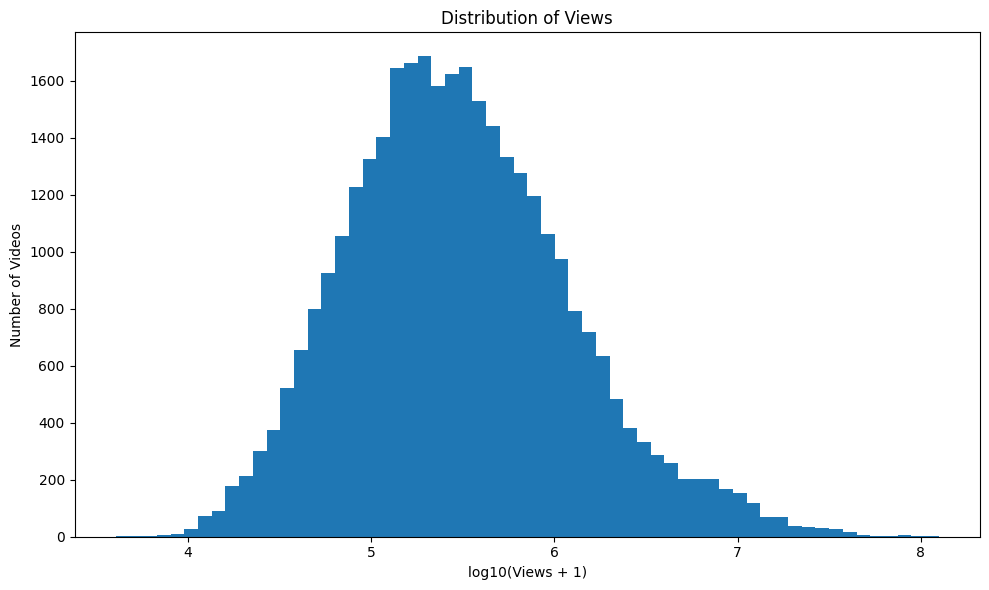

In [5]:
plt.figure(figsize=(10, 6))

plt.hist(
    np.log10(analysis["views"] + 1),
    bins=60
)

plt.title("Distribution of Views")
plt.xlabel("log10(Views + 1)")
plt.ylabel("Number of Videos")

plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_7500\2144058896.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


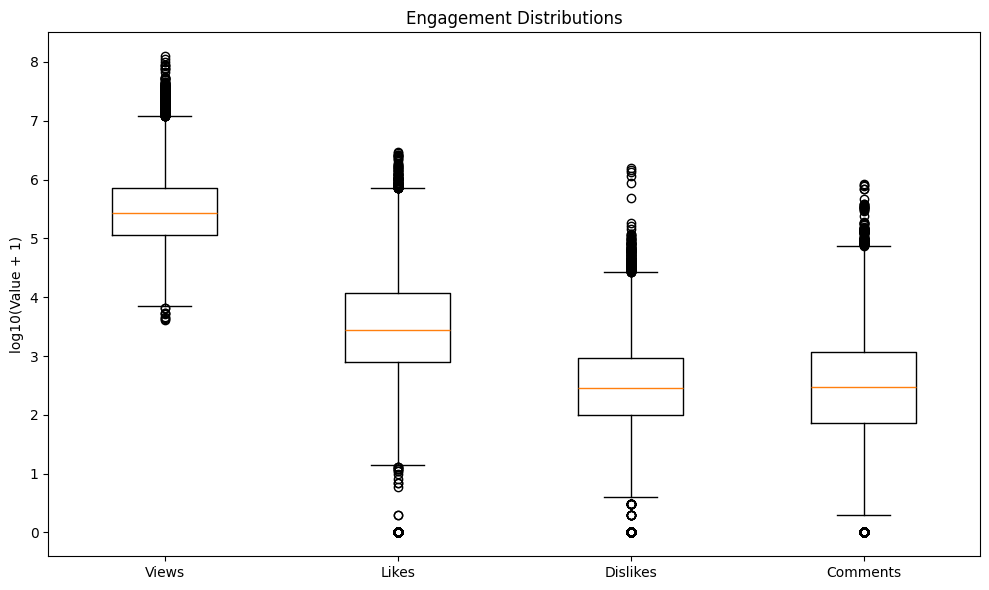

In [6]:
engagement_columns = [
    "views",
    "likes",
    "dislikes",
    "comment_count"
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    [
        np.log10(analysis[col] + 1)
        for col in engagement_columns
    ],
    labels=["Views", "Likes", "Dislikes", "Comments"]
)

plt.title("Engagement Distributions")
plt.ylabel("log10(Value + 1)")

plt.tight_layout()
plt.show()

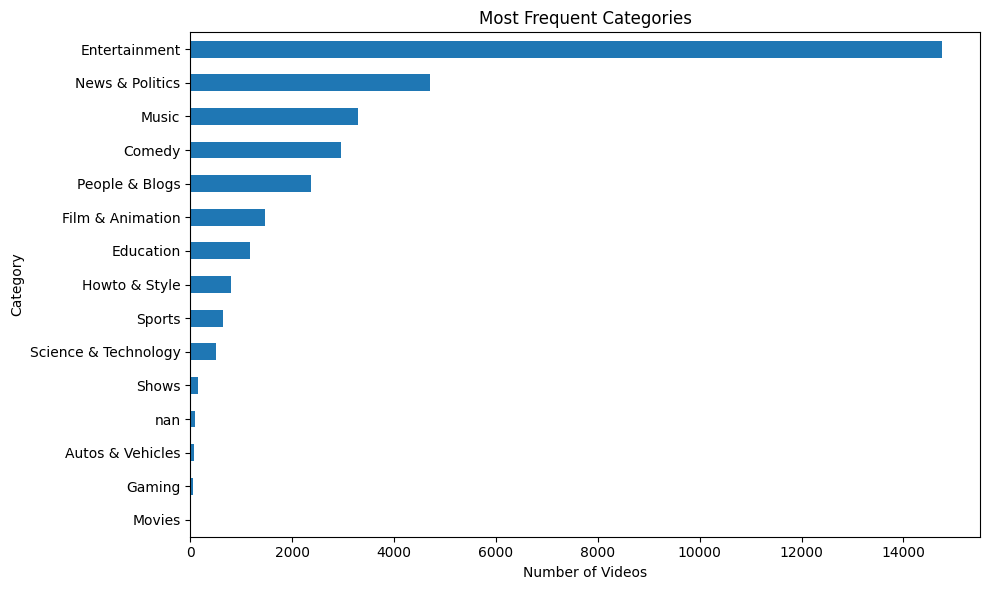

In [7]:
category_counts = (
    analysis["category_name"]
    .value_counts(dropna=False)
    .head(15)
)

plt.figure(figsize=(10, 6))

category_counts.sort_values().plot(kind="barh")

plt.title("Most Frequent Categories")
plt.xlabel("Number of Videos")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

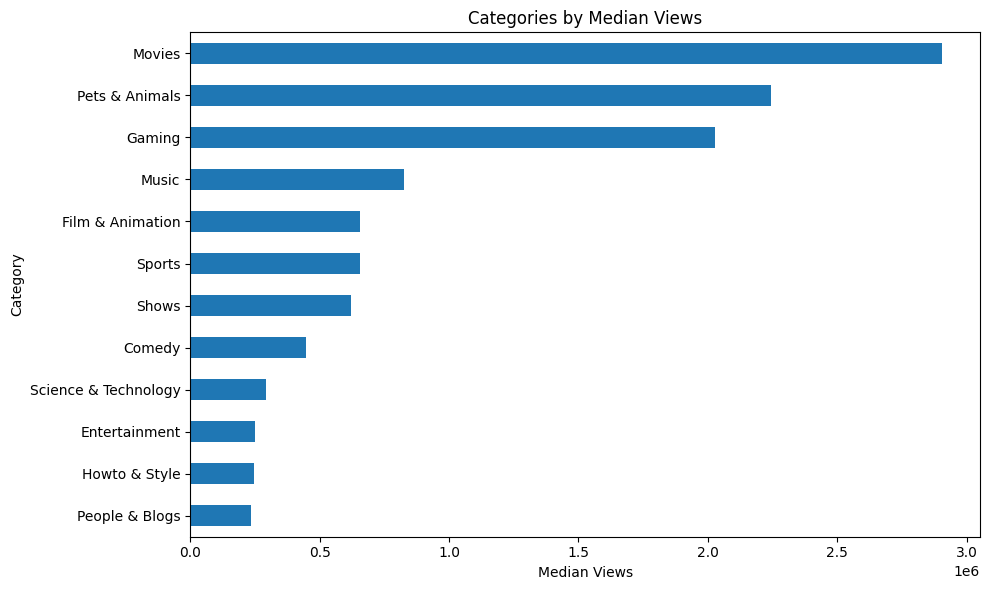

In [8]:
category_views = (
    analysis.groupby("category_name")["views"]
    .median()
    .sort_values(ascending=False)
    .head(12)
)

plt.figure(figsize=(10, 6))

category_views.sort_values().plot(kind="barh")

plt.title("Categories by Median Views")
plt.xlabel("Median Views")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

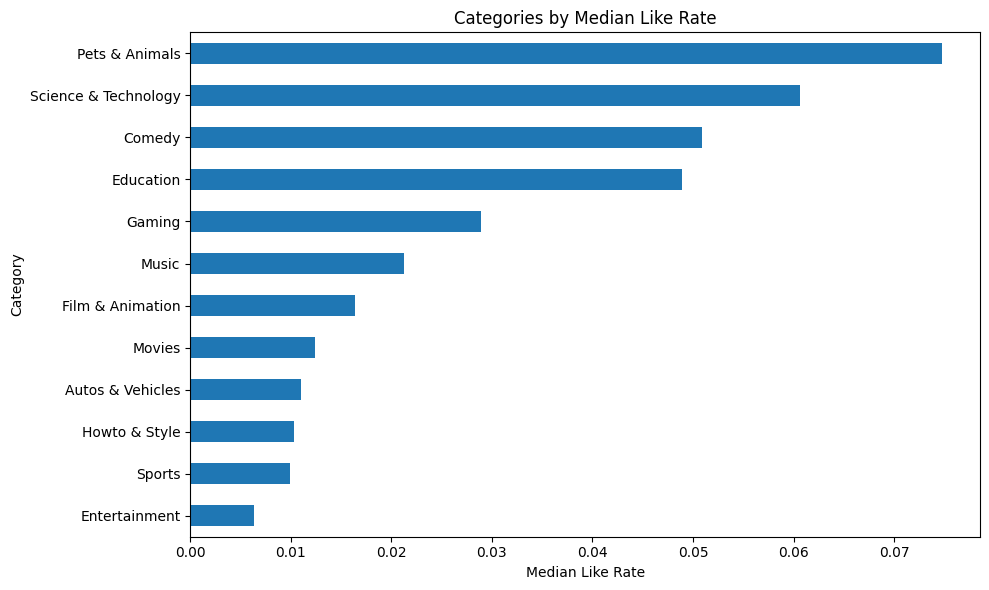

In [9]:
category_like_rate = (
    analysis.groupby("category_name")["like_rate"]
    .median()
    .sort_values(ascending=False)
    .head(12)
)

plt.figure(figsize=(10, 6))

category_like_rate.sort_values().plot(kind="barh")

plt.title("Categories by Median Like Rate")
plt.xlabel("Median Like Rate")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

In [10]:
print("Median views:", analysis["views"].median())
print("75th percentile:", analysis["views"].quantile(0.75))
print("95th percentile:", analysis["views"].quantile(0.95))
print("99th percentile:", analysis["views"].quantile(0.99))
print("Maximum views:", analysis["views"].max())

Median views: 275027.0
75th percentile: 732022.0
95th percentile: 3873490.7999999914
99th percentile: 12810824.239999989
Maximum views: 125432237


## Week 4 Observations

The exploratory analysis shows substantial variation in video reach and engagement.

The distributions of views and engagement are highly uneven, with a relatively small number of videos reaching exceptionally high values.

Category-level analysis also shows differences in the number of videos represented and their typical view and engagement levels.
